# 🎓 Predicting Student Mental Health Score from Social Media Usage
# Problem: 
We're predicting a student's Mental_Health_Score (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a regression problem since the target is a number, not a category.

# Dataset: 
Student_Social_Media_And_Mental_Health_Impact.csv — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.

# 1.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2.Load Dataset

In [2]:
df = pd.read_csv('../data/Student Social Media And Mental Health Impact.csv')

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


# 3.Check basic information

In [4]:
df.shape

(5000, 13)

In [5]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [7]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [8]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

# 4. Exploratory Data Analysis (EDA)

# 4.1 — Distribution of the target (Mental_Health_Score)

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

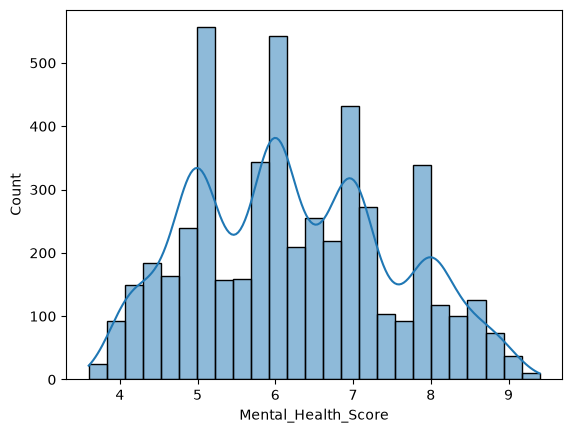

In [10]:
sns.histplot(df["Mental_Health_Score"], kde=True)

<Axes: xlabel='Mental_Health_Score'>

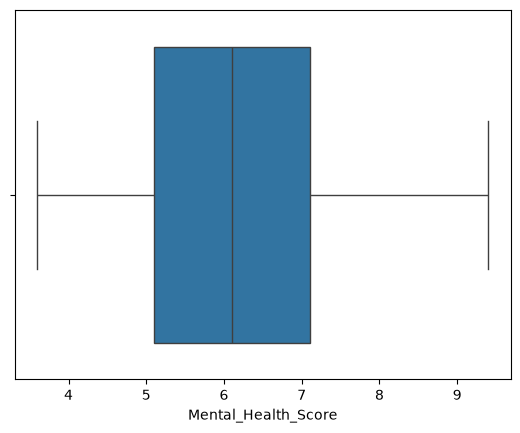

In [11]:
sns.boxplot(x=df["Mental_Health_Score"])

# 4.2 — Correlation heatmap

<Axes: >

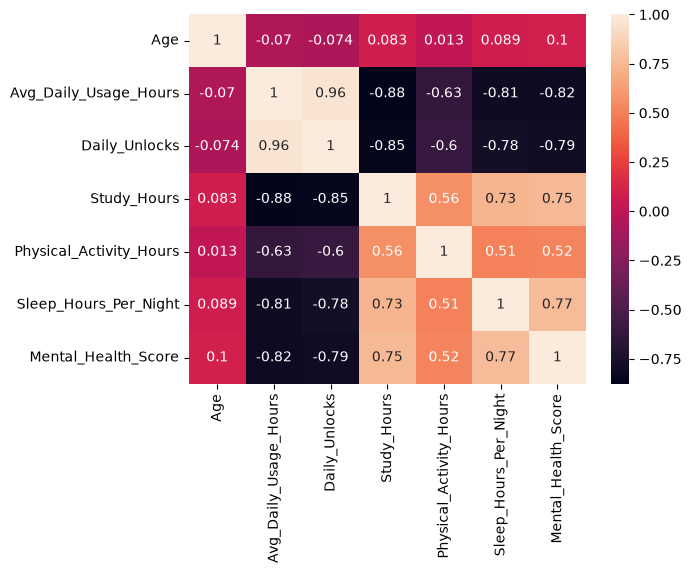

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# 4.3 Features individual EDA

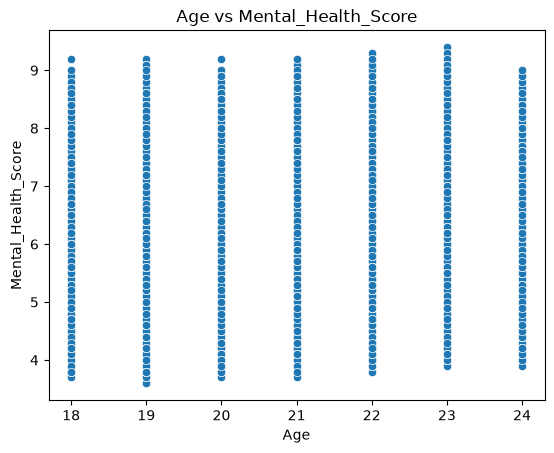

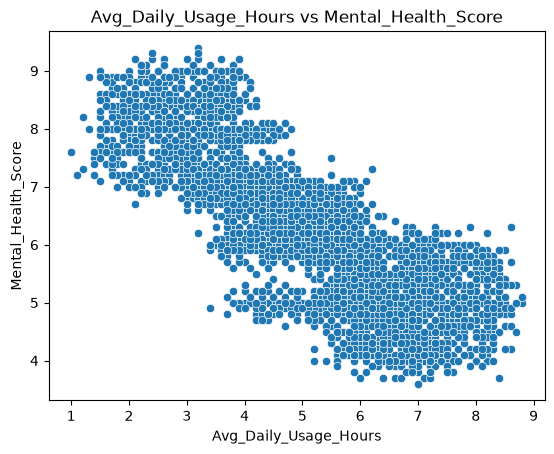

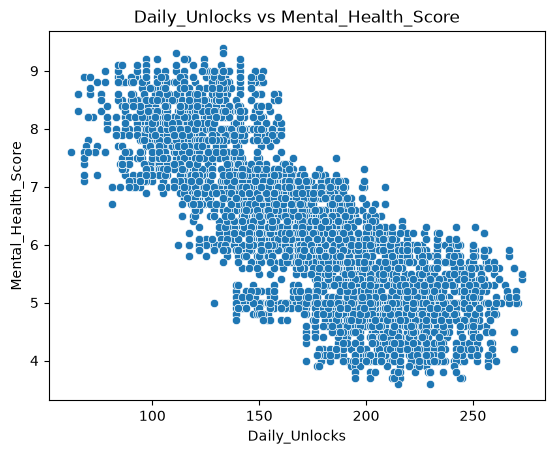

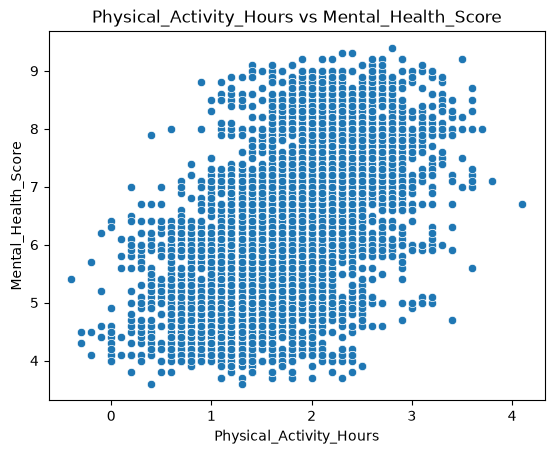

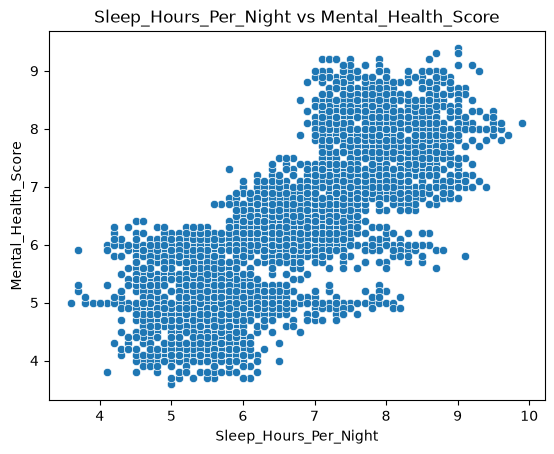

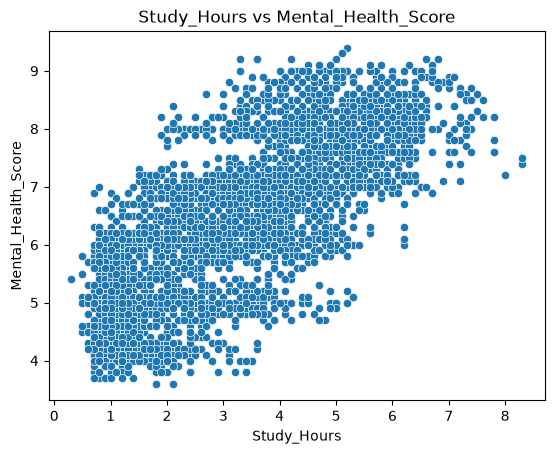

In [13]:
numerical_features = df.select_dtypes(include="number").columns.difference(["Mental_Health_Score"])

for col in numerical_features:
    sns.scatterplot(data=df, x=col, y="Mental_Health_Score")
    plt.title(f"{col} vs Mental_Health_Score")
    plt.show()

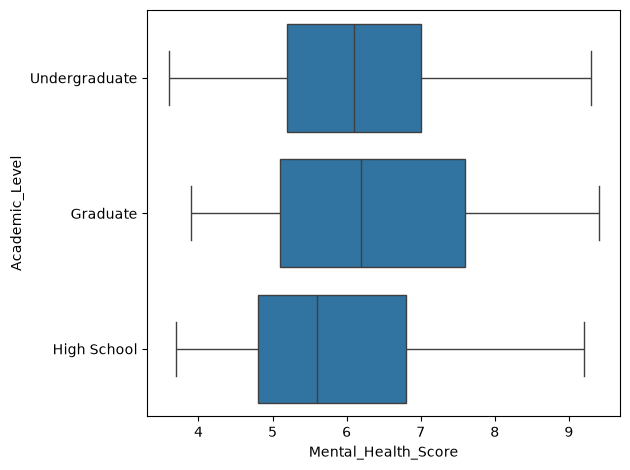

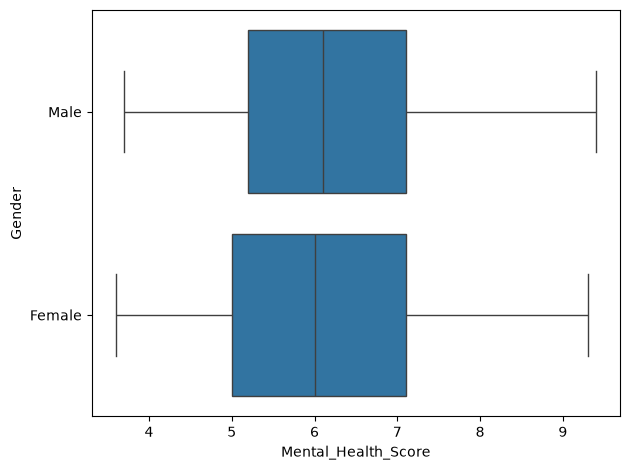

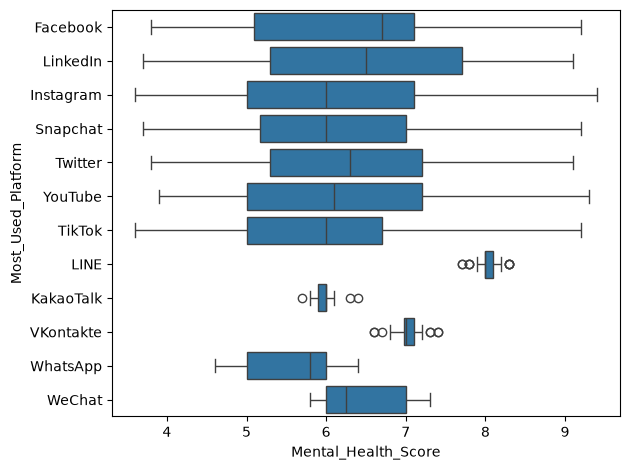

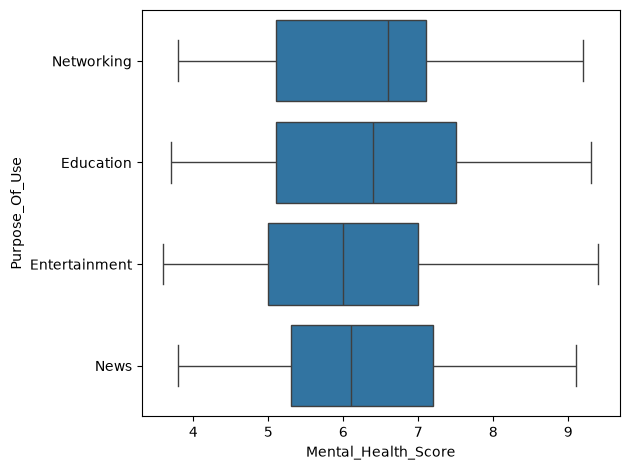

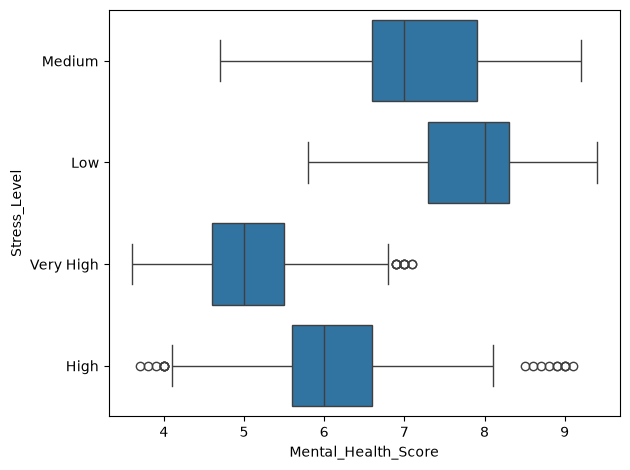

In [14]:
categorical_features = df.select_dtypes(include=["object", "string"]).columns.difference(["Country"])

for col in categorical_features:
    sns.boxplot(data=df, y=col, x="Mental_Health_Score")
    plt.tight_layout()
    plt.show()


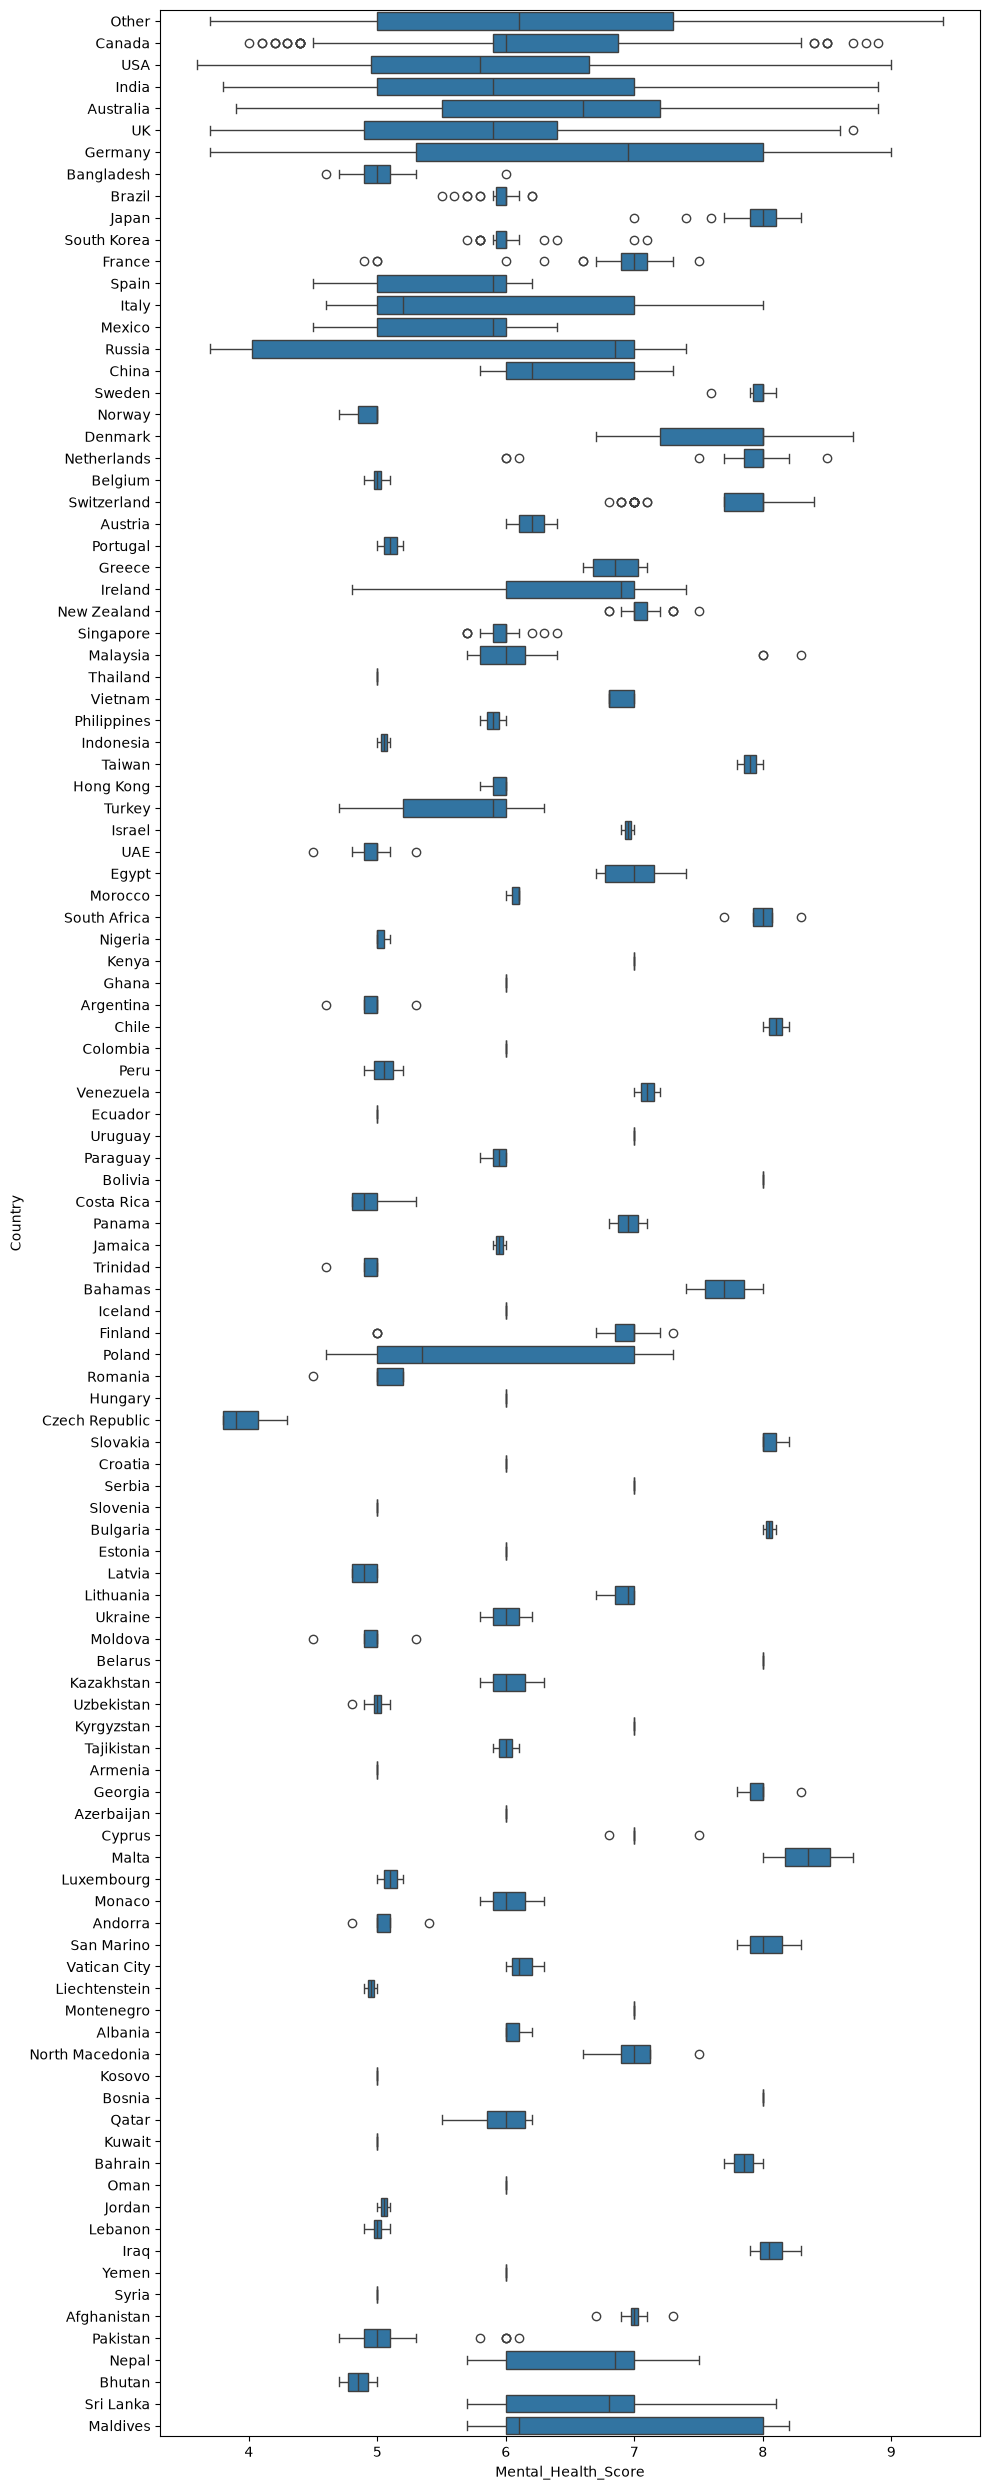

In [15]:
plt.figure(figsize=(10, 25))

sns.boxplot(data=df, y="Country", x="Mental_Health_Score")

plt.tight_layout()
plt.show()


# 4.6 — Most Used Platform (count)

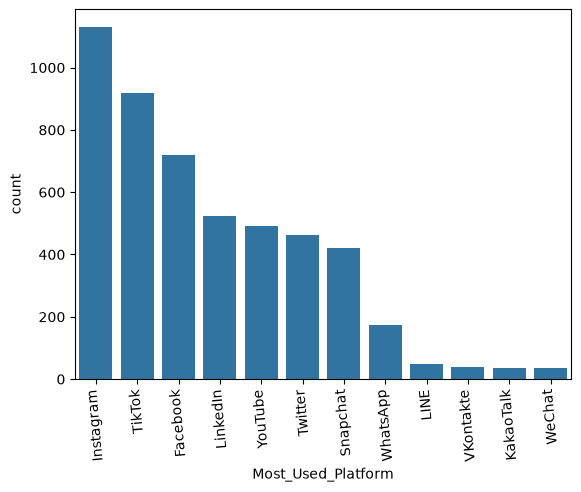

In [16]:
sns.countplot(x=df["Most_Used_Platform"], order=df["Most_Used_Platform"].value_counts().index)
plt.xticks(rotation=95)
plt.show()

# Checking Outliers

In [17]:
num_feature = df.select_dtypes(include="number")

Q1 = num_feature.quantile(0.25)
Q3 = num_feature.quantile(0.75)

IQR = Q3 - Q1

Upper_bound = Q3 + 1.5 * IQR
Lower_bound = Q1 - 1.5 * IQR

Outliers = (num_feature > Upper_bound ) | (num_feature < Lower_bound)
print(Outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# 5. Data Cleaning

In [18]:
#1. To drop duplicates
df = df.drop_duplicates()

#2. Converting negative or unrealitstic value to realistic value
df["Physical_Activity_Hours"]=df["Physical_Activity_Hours"].clip(lower=0)

# 6. Skewness

In [19]:
num_cols = df.select_dtypes(include="number")
num_cols.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

# 7. Feature Engineering

In [20]:
top_country = df["Country"].value_counts().index[:10].tolist()
top_country

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [21]:
def group_countries(country):
    if country in top_country:
        return country
    else:
        return 'Other'

In [22]:
df["Grouped_country"] = df["Country"].apply(group_countries)
df["Grouped_country"].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

# 8. Encoding Strategy
# **Stress_Level** = Ordinal encoding. 
Its categories have a real, meaningful order: Low < Medium < High < Very High. We already saw in EDA (section 4.3) that the score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.

# Gender, Academic_Level, Most_Used_Platform, Purpose_Of_Use, Grouped_country → One-Hot Encoding.
These categories have **no natural order** — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.
We'll implement both of these inside a single ColumnTransformer in the next step, rather than doing it manually column by column — that keeps preprocessing consistent and reusable.

# 9. Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

skewed_col = ["Study_Hours"]
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours","Sleep_Hours_Per_Night"]
ordinal_col = ["Stress_Level"]
normal_col = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]

feature_col = skewed_col + other_numeric_cols + ordinal_col + normal_col

X = df[feature_col]
y = df["Mental_Health_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 10. Preprocessing using ColumnTransformer
Our columns need **different treatment**:

Study_Hours (the skewed one) → impute → log1p transform → scale         
The other numeric columns → impute → scale (no skew to fix)
Stress_Level → impute → OrdinalEncoder with an **explicit order**
The nominal columns → impute → OneHotEncoder
We include a SimpleImputer in every branch even though this dataset has zero missing values right now — it's a safety net. 
Real-world data (and our future API's incoming requests) won't always be this clean, and a pipeline that assumes "no missing values ever" is a pipeline that breaks in production.

ColumnTransformer glues all of this into **one object** that applies the right transformation to the right column type in a single .fit() / .transform() call — no manual column-by-column juggling.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#1. Skewed features
skewed_pipeline = Pipeline(steps=[
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler())
])

#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

#3. Ordinal
ordinal_pipeline = Pipeline(steps=[
    ("encode", OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#4. Nominal Features
nominal_pipeline = Pipeline(steps=[
    ("encode", OneHotEncoder(handle_unknown='ignore'))
])

# (konsi_pipeline, konsa_feature)
preprocessor = ColumnTransformer(transformers=[
    ("skewed_Pipeline",skewed_pipeline, skewed_col),
    ("Plain_Numeric", plain_numeric_pipeline, other_numeric_cols),
    ("Ordinal", ordinal_pipeline, ordinal_col),
    ("Normal", nominal_pipeline, normal_col)
])



# 11. Build a Pipeline 
We'll build two pipelines below — one per model — so we can fairly compare them.

# 12. Model Building

# 12.1 — Baseline: Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regression", LinearRegression())
])

lr_pipeline.fit(X_train,y_train)
lr_predict_test   =  lr_pipeline.predict(X_test)
lr_predict_train  =  lr_pipeline.predict(X_train)

lr_r2_score_test  =  r2_score(y_test, lr_predict_test)
lr_r2_score_train =  r2_score(y_train, lr_predict_train)
lr_mae            =  mean_absolute_error(y_test, lr_predict_test)

print(f"Accuracy of training: {lr_r2_score_train}")
print(f"Accuracy of Testing: {lr_r2_score_test}")
print(f"MAE of Testing: {lr_mae}")


Accuracy of training: 0.7255672449830839
Accuracy of Testing: 0.7428129069013331
MAE of Testing: 0.5338894857575271


# 12.2 — Random Forest (default settings)

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("random forest", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_predict_test   =  rf_pipeline.predict(X_test)
rf_predict_train  =  rf_pipeline.predict(X_train)

rf_r2_score_test  =  r2_score(y_test, rf_predict_test)
rf_r2_score_train =  r2_score(y_train, rf_predict_train)
rf_mae            =  mean_absolute_error(y_test, rf_predict_test)

print(f"Accuracy of training: {rf_r2_score_train}")
print(f"Accuracy of Testing: {rf_r2_score_test}")
print(f"MAE of Testing: {rf_mae}")

Accuracy of training: 0.9827547524561985
Accuracy of Testing: 0.8903974263700929
MAE of Testing: 0.32654536666666667


# 12.3 — Hyperparameter Tuning the Random Forest

In [27]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "random forest__n_estimators"       : [100, 300, 500],
    "random forest__max_depth"          : [6, 12, 18],
    "random forest__min_samples_split"  : [2, 5, 8],
    "random forest__min_samples_leaf"   : [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator            = rf_pipeline,
    param_distributions  = param_grid,
    n_iter               = 15,
    cv                   = 5,
    scoring              = "r2",
    random_state         = 42,
    n_jobs               = -1 #processor free
)

random_search.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random forest__max_depth': [6, 12, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 300, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [28]:
print(random_search.best_params_)

{'random forest__n_estimators': 300, 'random forest__min_samples_split': 5, 'random forest__min_samples_leaf': 2, 'random forest__max_depth': 18}


In [29]:
rf_best_pipeline  =  random_search.best_estimator_
rf_best_predict  = rf_best_pipeline.predict(X_test)

print(f"R2 score of random forest after hyperparameter tuning: {r2_score(y_test, rf_best_predict)}" )
print(f"MAE of random forest after hyperparameter tuning:  {mean_absolute_error(y_test, rf_best_predict)}")


R2 score of random forest after hyperparameter tuning: 0.879919908442168
MAE of random forest after hyperparameter tuning:  0.34527640346650285


# 13. Model Evaluation

In [30]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predict_test))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predict_test))

# Calculate RMSE for tuned Random Forest
rf_tuned_predict        = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_predict))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_predict)
rf_tuned_r2             = r2_score(y_test, rf_tuned_predict)

results = pd.DataFrame({
    "Model"        : ["Linear Regression", "Random Forest (default)", "Random Forest (tuned)"],
    "R2"           : [lr_r2_score_test, rf_r2_score_test, rf_tuned_r2],
    "Training R2"  : [lr_r2_score_train, rf_r2_score_train, r2_tuned_training],
    "MAE"          : [lr_mae, rf_mae, rf_tuned_mae],
    "RMSE"         : [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.742813     0.725567  0.533889  0.677593
1  Random Forest (default)  0.890397     0.982755  0.326545  0.442339
2    Random Forest (tuned)  0.879920     0.964575  0.345276  0.462999


# 14. Save the Model

In [31]:
import joblib

joblib.dump(rf_pipeline, "Mental_Health_Model.pkl")

['Mental_Health_Model.pkl']

In [32]:
X.columns

Index(['Study_Hours', 'Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Stress_Level',
       'Gender', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use',
       'Grouped_country'],
      dtype='str')